# Learning with AIID Initial Exploration

## Core pandas concepts

**DataFrame** — a table. Rows and columns, like a spreadsheet. 
`df` is a DataFrame — 1,425 rows, one per incident.

**Series** — a single column, or any 1D list of values with an index. 
`df['year']` returns a Series — just the year values.


### How pandas memory works

- read_csv loads a copy into RAM — original file never changes
- All transformations happen on the in-memory DataFrame
- Variables disappear when kernel restarts — always re-run cells from top
- To save changes permanently: df.to_csv('path/to/file.csv', index=False)
- Raw data is always safe — never write back to /data/raw

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval

In [3]:
df = pd.read_csv("../data/raw/aiid_03302026/incidents.csv")
df.shape

(1425, 9)

In [4]:
df.dtypes

_id                                          str
incident_id                                int64
date                                         str
reports                                      str
Alleged deployer of AI system                str
Alleged developer of AI system               str
Alleged harmed or nearly harmed parties      str
description                                  str
title                                        str
dtype: object

In [5]:
df.head(10)

,_id,incident_id,date,reports,Alleged deployer of AI system,Alleged developer of AI system,Alleged harmed or nearly harmed parties,description,title
0,ObjectId(625763de343edc875fe63a15),23,2017-11-08,"[242,243,244,245,246,247,248,249,250,253,254,2...","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america"",""bus-passengers""]",A self-driving public shuttle by Keolis North ...,Las Vegas Self-Driving Bus Involved in Accident
1,ObjectId(625763dc343edc875fe63a02),4,2018-03-18,"[629,630,631,632,633,634,635,636,637,638,639,6...","[""uber""]","[""uber""]","[""elaine-herzberg"",""pedestrians""]",An Uber autonomous vehicle (AV) in autonomous ...,Uber AV Killed Pedestrian in Arizona
2,ObjectId(625763db343edc875fe639ff),1,2015-05-19,"[2,3,4,5,6,7,8,9,10,11,12,14,15]","[""youtube""]","[""youtube""]","[""children""]",YouTube’s content filtering and recommendation...,Google’s YouTube Kids App Presents Inappropria...
3,ObjectId(625763de343edc875fe63a10),18,2015-04-04,"[130,131,132,133,134,135,136,137,138,1367]","[""google""]","[""google""]","[""women""]",Google Image returns results that under-repres...,Gender Biases of Google Image Search
4,ObjectId(625763dd343edc875fe63a0a),12,2016-07-21,[42],"[""microsoft-research"",""boston-university""]","[""microsoft-research"",""google"",""boston-univers...","[""women"",""minority-groups""]",Researchers from Boston University and Microso...,Common Biases of Vector Embeddings
5,ObjectId(625763dd343edc875fe63a0d),15,2008-05-23,"[57,58,59,60,61,62,63,64,65,66,67,68,69,70,72,...","[""amazon""]","[""amazon""]","[""amazon-customers""]","Amazon's book store ""cataloging error"" led to ...",Amazon Censors Gay Books
6,ObjectId(625763dc343edc875fe63a05),7,2017-02-24,"[1123,1125,1126,1127,1129,1130]","[""wikipedia""]","[""wikipedia""]","[""wikimedia-foundation"",""wikipedia-editors"",""w...",Wikipedia bots meant to remove vandalism clash...,Wikipedia Vandalism Prevention Bot Loop
7,ObjectId(625763dc343edc875fe63a03),5,2015-07-13,"[767,768,769,771,772,773,774,775,776,777,778]","[""hospitals"",""doctors""]","[""intuitive-surgical""]","[""patients""]",Study on database reports of robotic surgery m...,Collection of Robotic Surgery Malfunctions
8,ObjectId(625763dc343edc875fe63a04),6,2016-03-24,"[906,908,909,910,911,912,913,914,915,916,917,9...","[""microsoft""]","[""microsoft""]","[""twitter-users""]","Microsoft's Tay, an artificially intelligent c...","Microsoft's TayBot Allegedly Posts Racist, Sex..."
9,ObjectId(625763dd343edc875fe63a08),10,2014-08-14,"[16,17,19,20,21,22,23,24,25]","[""starbucks""]","[""kronos""]","[""starbucks-employees""]",Kronos’s scheduling algorithm and its use by S...,Kronos Scheduling Algorithm Allegedly Caused F...


In [6]:
print(df.info()) 


<class 'pandas.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   _id                                      1425 non-null   str  
 1   incident_id                              1425 non-null   int64
 2   date                                     1425 non-null   str  
 3   reports                                  1425 non-null   str  
 4   Alleged deployer of AI system            1425 non-null   str  
 5   Alleged developer of AI system           1425 non-null   str  
 6   Alleged harmed or nearly harmed parties  1425 non-null   str  
 7   description                              1425 non-null   str  
 8   title                                    1425 non-null   str  
dtypes: int64(1), str(8)
memory usage: 100.3 KB
None


In [7]:
df.isnull().sum()


_id                                        0
incident_id                                0
date                                       0
reports                                    0
Alleged deployer of AI system              0
Alleged developer of AI system             0
Alleged harmed or nearly harmed parties    0
description                                0
title                                      0
dtype: int64

There are 1,425 incidents, 9 columns.

Observations: 
- date is an object (string), not a datetime --> need to convert it before you can do any time-based analysis.

- reports contains a list of report IDs in brackets (many-to-many relationship encoded as a string)

- Alleged deployer, Alleged developer, and Alleged harmed parties all contain lists in string format — ["uber"], ["navya","keolis-north-america"]. Need special handling.

- use incident_id as your key.

In [8]:
# How far back does the data go?
print(df['date'].min())
print(df['date'].max())

1983-09-26
2026-03-19


### Panda Tutorial

- pd.to_datetime() converts a string column into a proper datetime type
- Once a column is datetime type, .dt gives you access to components of the date: .dt.year, .dt.month, .dt.day
- value_counts()
- .sort_index()
- plot(kind='bar') built-in plotting that wraps matplotlib
- pandas DataFrame plot bar chart 
- sortindex() Returns a new DataFrame

In [9]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
print(df['year'].value_counts().sort_index())


year
1983      1
1992      1
1996      1
1998      1
1999      1
2003      4
2006      1
2007      1
2008      3
2009      2
2010      1
2011      3
2012      8
2013      6
2014     13
2015     24
2016     41
2017     51
2018     45
2019     43
2020     90
2021     78
2022    105
2023    168
2024    284
2025    392
2026     57
Name: count, dtype: int64


## Plotting Panda

In [10]:
#Doesn't work... 
# ax = df.plot.bar (x=df['date'].dt.year, y=df['year'].value_counts(), rot=0)

- df.plot.bar() expects x and y to be column names as strings, not actual series objects.
- df has 1,425 rows — one per incident. You can't plot that directly as a bar chart meaningfully. You first need to aggregate it down to one row per year, then plot that smaller summary table.

In [ ]:
df['number of incidents'] = df['year'].value_counts()
ax = df.plot.bar (x="year", y="number of incidents", rot=0)

Still doesn't work... 

When you write df['number of incidents'] = df['year'].value_counts(), you're trying to assign a summary Series (one value per year) back into a DataFrame that has 1,425 rows. Pandas will try to align them by index and most rows will get NaN. The shapes don't match.

### The key rule: operations on a DataFrame column return a Series, not a DataFrame.

`df['year'].value_counts()` → returns a Series where:
- index = unique years (2015, 2016, 2017...)  
- values = count of incidents per year
- length = number of unique years, NOT 1,425

**Why this matters for plotting:**
You can't assign a short Series back into a long DataFrame. The shapes don't match.
Always aggregate into a *separate* summary object first, then plot that.

**The two-step rule**
1. Summarize first → `incidents_per_year = df['year'].value_counts().sort_index()`
2. Plot the summary → `incidents_per_year.plot(...)`

Never plot the raw DataFrame directly for aggregated charts.

plt functions style the *current active chart*:
These are always called *after* the plot command, before `plt.show()'

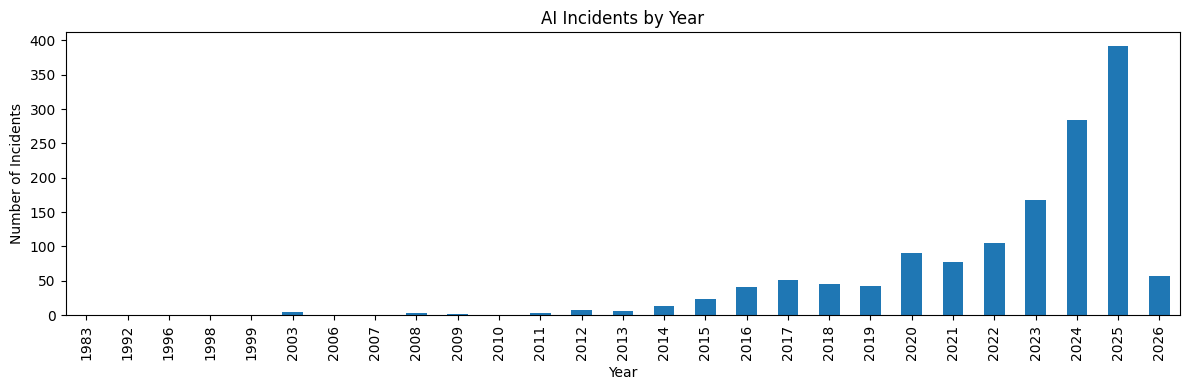

In [12]:
# Incidents per year as a quick plot - bar chart
incidentbyyear = df['year'].value_counts().sort_index()
incidentbyyear.plot(kind='bar', figsize=(12,4), title='AI Incidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

/var/folders/t5/w7qvl8g51mz5k7d3kg5b6sm80000gn/T/ipykernel_31123/3074630910.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


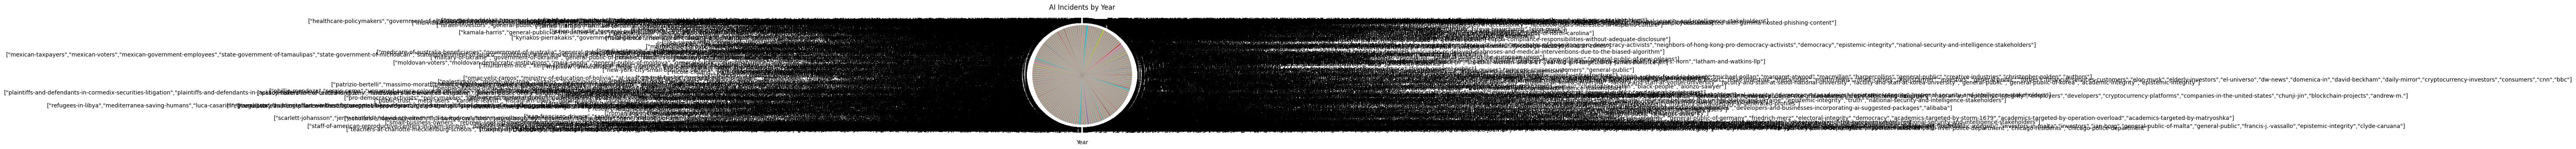

In [13]:
# Incidents per year as a quick plot
df['Alleged harmed or nearly harmed parties'].value_counts().sort_index().plot(kind='pie', figsize=(12,4), title='AI Incidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

## Analysis By Categories

From before, we noticed Alleged deployer, Alleged developer, and Alleged harmed parties all contain lists in string format ["uber"], ["navya","keolis-north-america"]. It requires special handling.

### Without special handling

In [14]:

# What do the alleged deployer values actually look like?
print(df['Alleged deployer of AI system'].value_counts().head(10))

Alleged deployer of AI system
["openai"]              43
["google"]              42
["tesla"]               41
["unknown-scammers"]    41
["facebook"]            36
["unknown"]             26
["amazon"]              21
["meta"]                17
["microsoft"]           15
["cruise"]              13
Name: count, dtype: int64


In [15]:
# What do the alleged harmed values actually look like?
print(df['Alleged harmed or nearly harmed parties'].value_counts().head(10))

Alleged harmed or nearly harmed parties
["facebook-users"]             7
["general-public"]             7
["tesla-drivers"]              6
["women","minority-groups"]    5
["tiktok-users"]               5
["chatgpt-users"]              5
["children"]                   4
["unknown"]                    4
["microsoft"]                  4
["women"]                      3
Name: count, dtype: int64


It looks right, but it is actually not counting those with ["openai", "something else"].

The values look like JSON arrays but they're actually just strings. The quotes around the whole thing. ["navya","keolis-north-america","bus-passengers"] is one string, not a list.

**Problem 1** — parse the strings into actual lists. We need to convert "[\"navya\",\"keolis-north-america\"]" into a real Python list ["navya", "keolis-north-america"].

We need to use ast.literal_eval, a built-in Python function that safely parses a string that looks like a Python object into the actual object.

**Problem 2** — explode the lists. Once each cell contains a real list, we need to flatten it so each individual value gets its own row.

The column contains at least three different types of values: named individuals, demographic groups, and abstract integrity concepts. That mix will affect how we interpret our frequency chart.

### With apply_literals and explode

In [16]:
# Explode Method - what is the unit of one row I need?

# Step 1: parse the string into a real Python list
#   apply literal_eval to each cell individually, row by row
df['deployers'] = df['Alleged deployer of AI system'].apply(literal_eval)

print(f"Before literal_eval:            {df['Alleged deployer of AI system'][0]}")
print(f"Type before literal_eval:       {type(df['Alleged deployer of AI system'][0])}")
print(f"After literal_eval:             {df['deployers'][0]}")
print(f"Type after literal_eval:        {type(df['deployers'][0])}")

# Step 2: explode ONE column at a time into a separate dataframe
deployers_df = df[['incident_id', 'date', 'deployers']].explode('deployers')

# Now deployers_df has one row per incident-deployer pair

Before literal_eval:            ["navya","keolis-north-america"]
Type before literal_eval:       <class 'str'>
After literal_eval:             ['navya', 'keolis-north-america']
Type after literal_eval:        <class 'list'>


In [17]:
# The pattern is identical for every list column: parse → explode → new dataframe
# Apply this pattern for developers and harmed
# Each produces a different number of rows because incidents have different numbers of developers vs deployers

developers_df = df[['incident_id', 'date', 'year', 'Alleged developer of AI system']].copy()
developers_df['developer'] = developers_df['Alleged developer of AI system'].apply(literal_eval)
developers_df = developers_df[['incident_id', 'date', 'year', 'developer']].explode('developer')

harmed_df = df[['incident_id', 'date', 'year', 'Alleged harmed or nearly harmed parties']].copy()
harmed_df['harmed_party'] = harmed_df['Alleged harmed or nearly harmed parties'].apply(literal_eval)
harmed_df = harmed_df[['incident_id', 'date', 'year', 'harmed_party']].explode('harmed_party')

print(f"Original incidents:  {len(df)}")
print(f"Deployer rows:       {len(deployers_df)}  (one row per incident-deployer pair)")
print(f"Developer rows:      {len(developers_df)}  (one row per incident-developer pair)")
print(f"Harmed party rows:   {len(harmed_df)}  (one row per incident-harmed party pair)")

Original incidents:  1425
Deployer rows:       2494  (one row per incident-deployer pair)
Developer rows:      2103  (one row per incident-developer pair)
Harmed party rows:   4755  (one row per incident-harmed party pair)


We went from **1 dataframe** to **4**:

| DataFrame | Unit of one row | Use it to answer |
|---|---|---|
| `df` | one incident | How many incidents per year? |
| `deployers_df` | one incident-deployer pair | Which companies appear most often as deployers? |
| `developers_df` | one incident-developer pair | Which companies built the most implicated systems? |
| `harmed_df` | one incident-harmed party pair | Who gets hurt most often? |

**The key insight:** each dataframe has a different row count because `value_counts()` and `groupby()` just count rows. If you want to count deployers, you need a dataframe where each deployer has its own row.

You can always trace back to the original incident via `incident_id` — that column is preserved in all four dataframes.

In [18]:
# Top deployers
top_deployers = deployers_df['deployers'].value_counts().head(15)

print(top_deployers)

deployers
unknown-scammers                 171
openai                            66
google                            61
facebook                          54
tesla                             43
meta                              42
microsoft                         29
amazon                            28
unknown                           27
unknown-deepfake-creators         27
unknown-actors                    21
xai                               17
unknown-disinformation-actors     16
youtube                           14
apple                             14
Name: count, dtype: int64


In [19]:
# Top harmed parties
top_harmed = harmed_df['harmed_party'].value_counts().head(15)

print(top_harmed)

harmed_party
general-public                                     253
epistemic-integrity                                212
truth                                               61
national-security-and-intelligence-stakeholders     59
democracy                                           57
electoral-integrity                                 45
facebook-users                                      43
minors                                              27
tesla-drivers                                       23
social-media-users                                  23
women                                               20
chatgpt-users                                       20
investors                                           20
donald-trump                                        20
tiktok-users                                        18
Name: count, dtype: int64


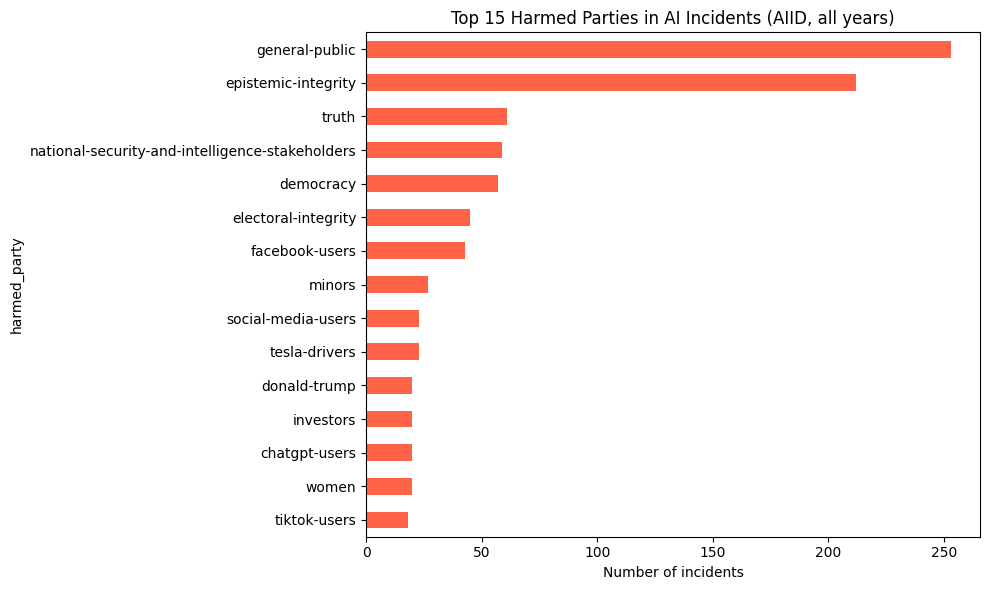

harmed_party
general-public                                     253
epistemic-integrity                                212
truth                                               61
national-security-and-intelligence-stakeholders     59
democracy                                           57
electoral-integrity                                 45
facebook-users                                      43
minors                                              27
tesla-drivers                                       23
social-media-users                                  23
women                                               20
chatgpt-users                                       20
investors                                           20
donald-trump                                        20
tiktok-users                                        18
Name: count, dtype: int64


In [20]:
# Visualizing 

top_harmed.sort_values().plot(kind='barh', figsize=(10, 6), color='tomato')
plt.title('Top 15 Harmed Parties in AI Incidents (AIID, all years)')
plt.xlabel('Number of incidents')
plt.tight_layout()
plt.show()

print(top_harmed)

## Data Operations Based on Explode


| Question type | Operation | Why |
|---|---|---|
| Filtering one column | filter → count | We already have the right shape |
| Two columns from different exploded dfs | merge on incident_id → filter → count | Connect them via shared key first |
| Exploded data + classification label | join on incident_id → groupby | Attach incident-level labels to entity-level rows |


### Filtering one column

**How has Tesla's incident count changed over time?**

<Axes: title={'center': 'Tesla Incidents by Year'}, xlabel='date'>

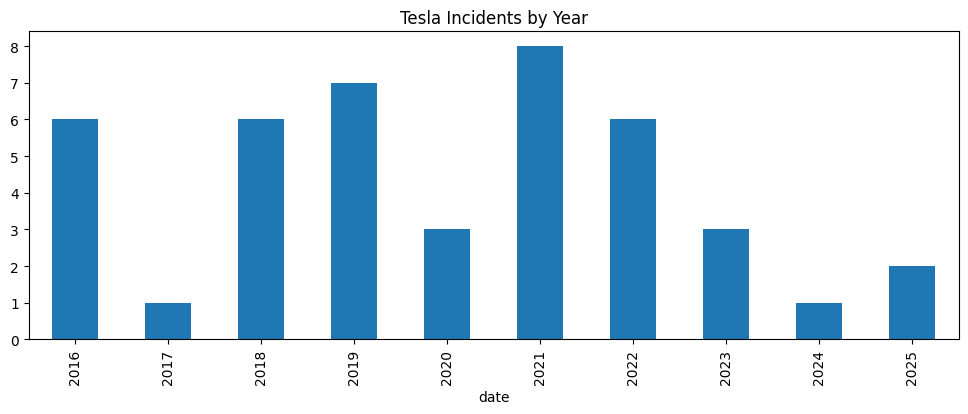

In [21]:
tesla_df = deployers_df[deployers_df['deployers'] == 'tesla']
tesla_incident = pd.to_datetime(tesla_df['date']).dt.year
tesla_incident = tesla_incident.value_counts().sort_index()

tesla_incident.plot(kind='bar', figsize=(12,4), title='Tesla Incidents by Year')


### Combine the two dataframes using shared key

**Which harmed parties appear most in incidents involving Tesla?**

In [ ]:
# Combine the two exploded dataframes using incident_id as the shared key
combined = deployers_df.merge(harmed_df, on='incident_id')

tesla_incidents = combined[combined['deployers'] == 'tesla']
tesla_incidents['harmed_party'].value_counts()


harmed_party
tesla-drivers                              22
motorists                                   3
pedestrians                                 3
tesla                                       2
tesla-users                                 2
traffic-participants                        2
joshua-brown                                1
jovani-maldonado                            1
benjamin-maldonado                          1
california-public                           1
gilberto-alcazar-lopez                      1
maria-guadalupe-nieves-lopez                1
eric-horvitz                                1
tesla-owner                                 1
vision-jet-owner                            1
road-engineer                               1
delivery-truck                              1
yoshihiro-umeda                             1
jeremy-beren-banner                         1
gao-yaning                                  1
landon-embry                                1
motorcyclists        

In [32]:
# Investigate cases of tesla harm tesla
tesla_harmed_testla = tesla_incidents[tesla_incidents['harmed_party'] == 'tesla']
print(tesla_harmed_testla)

# Our tesla dataframe which was derived from deployer_df did not include the description data 
# We can extract the description in the original df using incident ID

incident_30_des= df.loc[df['incident_id'] == 30, 'description'].iloc[0]

print(incident_30_des)


      incident_id     date_x deployers     date_y  year harmed_party
68             30 2016-10-08     tesla 2016-10-08  2016        tesla
1197          478 2016-09-09     tesla 2016-09-09  2016        tesla
The goal of manufacturing 2,500 Tesla Model 3's per week was falling short by 500 cars/week, and employees had to be "borrowed" from Panasonic in a shared factory to help hand-assemble lithium batteries for Tesla.


- .loc[condition, column] — filter rows AND select a column in one step. More precise than chaining [][].
- .iloc[0] — the filter returns a Series (could be multiple matches). .iloc[0] pulls just the first value as a plain string.

## Exploded data + classification label

**Do incidents with protected characteristics involve different deployers?**

In [34]:
cset = pd.read_csv('../data/raw/aiid_03302026/classifications_CSETv1.csv')

# CSET has one row per incident, with a 'Protected Characteristic' column (yes/no/maybe)
# Join it onto deployers_df using incident_id

deployers_with_cset = deployers_df.merge(cset[['Incident ID', 'Protected Characteristic']], 
                                          left_on='incident_id', 
                                          right_on='Incident ID')

# Now compare: which deployers appear in 'yes' vs 'no' incidents?
deployers_with_cset.groupby('Protected Characteristic')['deployers'].value_counts()


Protected Characteristic  deployers                  
maybe                     facebook                        2
                          international-baccalaurette     1
                          twitter                         1
                          ets                             1
no                        amazon                         11
                                                         ..
yes                       ibm                             1
                          twitter                         1
                          dutch-tax-authority             1
                          predpol                         1
                          rite-aid                        1
Name: count, Length: 185, dtype: int64

CSET has a label (protected characteristic: yes/no/maybe) for 214 incidents. deployers_df has deployers for 1,425 incidents. Merging them gives us only the 214 incidents that have CSET annotations, with both the deployer name and the protected characteristic label on each row.

Then groupby splits those rows into buckets ("yes" bucket, "no" bucket) and counts deployers within each bucket.

**Which deployers appear most in incidents where tangible harm definitively occurred?** Additional Exercise
1. Which column in cset tells you whether harm occurred, and what exact string value means "yes, harm happened"
2. How to join cset onto deployers_df using incident_id
3. How to filter to only the "harm occurred" rows
4. How to count and rank deployers


In [39]:
print(type(cset))

display(cset)

<class 'pandas.DataFrame'>


,Namespace,Incident ID,Published,Incident Number,Annotator,Annotation Status,Peer Reviewer,Quality Control,Physical Objects,Entertainment Industry,...,Data Inputs,Sector of Deployment,Public Sector Deployment,Autonomy Level,Notes (Information about AI System),Intentional Harm,Physical System Type,AI Task,AI tools and methods,Notes (AI Functionality and Techniques)
0,CSETv1,250,False,0,NaN,--,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CSETv1,208,False,0,NaN,--,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CSETv1,204,False,0,NaN,--,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CSETv1,100,True,100,3.0,4. Peer review complete,1.0,False,no,no,...,welfare recipient data,"administrative and support service activities,...",yes,Autonomy2,NaN,No. Not intentionally designed to perform harm,NaN,welfare determination,NaN,Fraud detection
4,CSETv1,124,True,124,NaN,4. Peer review complete,1.0,False,no,no,...,"patient data, treatment cost",human health and social work activities,maybe,unclear,9.4. - It is unclear whether the deploying hos...,No. Not intentionally designed to perform harm,NaN,"assign risk , predict healthcare needs",prediction,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,CSETv1,393,True,393,NaN,4. Peer review complete,1.0,False,no,maybe,...,"Facebook ads, Facebook posts","Arts, entertainment and recreation",no,Autonomy1,NaN,No. Not intentionally designed to perform harm,NaN,content moderation,NaN,NaN
210,CSETv1,583,True,583,NaN,4. Peer review complete,1.0,False,no,maybe,...,"Instagram accounts, Instagram posts","Arts, entertainment and recreation",no,Autonomy1,"9.5 - ""Due to the widespread use of hashtags, ...",No. Not intentionally designed to perform harm,NaN,content recommendation,NaN,NaN
211,CSETv1,205,True,205,NaN,4. Peer review complete,1.0,False,no,maybe,...,"social media accounts, Facebook accounts, Inst...","Arts, entertainment and recreation, informatio...",no,Autonomy3,NaN,unclear,NaN,NaN,NaN,no AI - AI was only used by the hackers to gen...
212,CSETv1,603,True,603,NaN,4. Peer review complete,1.0,False,maybe,no,...,"286 questions, health measures, patient inform...",human health and social work activities,yes,Autonomy3,NaN,No. Not intentionally designed to perform harm,NaN,"welfare determination, benefits allocation",NaN,NaN


In [54]:
print(cset.columns)


Index(['Namespace', 'Incident ID', 'Published', 'Incident Number', 'Annotator',
       'Annotation Status', 'Peer Reviewer', 'Quality Control',
       'Physical Objects', 'Entertainment Industry',
       'Report, Test, or Study of data', 'Deployed',
       'Producer Test in Controlled Conditions',
       'Producer Test in Operational Conditions',
       'User Test in Controlled Conditions',
       'User Test in Operational Conditions', 'Harm Domain', 'Tangible Harm',
       'AI System', 'Clear link to technology',
       'There is a potentially identifiable specific entity that experienced the harm',
       'AI Harm Level', 'AI Tangible Harm Level Notes',
       'Impact on Critical Services', 'Rights Violation', 'Involving Minor',
       'Detrimental Content', 'Protected Characteristic',
       'Harm Distribution Basis', 'Notes (special interest intangible harm)',
       'Special Interest Intangible Harm', 'AI System.1',
       'Clear link to Technology', 'Harmed Class of Entities',
  

In [ ]:
# value_counts counts occurrences of each unique value in one column.
print(cset["Tangible Harm"].value_counts())

Tangible Harm
no tangible harm, near-miss, or issue                     94
tangible harm definitively occurred                       72
non-imminent risk of tangible harm (an issue) occurred    18
imminent risk of tangible harm (near miss) did occur      14
unclear                                                    3
Name: count, dtype: int64


In [51]:
# groupby() — splits rows into buckets by one column, then lets you aggregate another column.

cset.groupby('Tangible Harm')['Harm Distribution Basis'].value_counts()


Tangible Harm                                           Harm Distribution Basis                                                                                                                                             
imminent risk of tangible harm (near miss) did occur    none                                                                                                                                                                    12
                                                        race                                                                                                                                                                     1
                                                        sexual orientation or gender identity                                                                                                                                    1
no tangible harm, near-miss, or issue                   none                                      

In [ ]:
combined_cset = deployers_df.merge(cset, left_on = 'incident_id', right_on='Incident ID')

tangible_harm_definite = combined_cset[combined_cset["Tangible Harm"] == "tangible harm definitively occurred"]
tangible_harm_definite['deployers'].value_counts()

deployers
tesla                            7
amazon                           6
facebook                         4
uber                             3
google                           3
                                ..
arkansas-state-government        1
washington-dc-government         1
pennsylvania-state-government    1
iowa-state-government            1
missouri-state-government        1
Name: count, Length: 70, dtype: int64

## The core operations map
| Question shape | Operation | Chart it enables | 
| - | - | - |
|How many per category?	| value_counts()	| bar chart|
|How does X break down by Y?	| groupby + aggregate	| grouped bar, heatmap |
|How do two categories relate?	|crosstab / pivot_table	|heatmap, matrix |
|How does something change over time?	|resample	|line chart|
|Is X in this list?	|isin	|filter before any chart|
|Wide table → plottable table	|melt	|grouped bar, facets|



In [71]:
# Matrix: deployer vs year

# pd.crosstab(deployers_df['deployers'], df['year'])
# deployers_df has 2494 rows. df has 1425 rows. crosstab needs both inputs to be the same length

# pd.crosstab(deployers_df['deployers'], deployers_df['year'])
# duplicate index from explosion, we need to collapse it 

deployers_df.index[:6]

deployers_df = deployers_df.reset_index(drop=True)
deployers_df['year'] = deployers_df['date'].dt.year
pd.crosstab(deployers_df['deployers'], deployers_df['year'])



year,1983,1992,1996,1998,1999,2003,2006,2007,2008,2009,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
deployers,,,,,,,,,,,,,,,,,,,,,
0xhungusman,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
15.ai,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4chan-users,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
@conflictcompas-youtube-channel,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
@daddymaxwell77-youtube-channel,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zhang-moumou,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
zhihu,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
zhou-moumou,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [72]:
top_names = deployers_df['deployers'].value_counts().head(15).index
top_df = deployers_df[deployers_df['deployers'].isin(top_names)]
pd.crosstab(top_df['deployers'], top_df['year'])



year,2006,2008,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
deployers,,,,,,,,,,,,,,,,,,
amazon,0,1,0,0,0,1,1,3,2,5,1,2,5,1,2,0,2,2
apple,0,0,1,0,0,0,0,0,3,0,1,1,1,2,1,2,2,0
facebook,1,0,0,0,0,2,4,1,3,5,4,12,12,4,1,5,0,0
google,0,0,1,1,1,0,5,3,7,2,0,2,1,5,6,12,14,1
meta,1,0,0,0,0,0,0,0,0,1,1,1,1,3,5,15,13,1
microsoft,0,0,0,0,0,0,0,1,0,1,0,2,0,0,13,4,8,0
openai,0,0,0,0,0,0,0,1,0,1,2,3,1,6,10,15,25,2
tesla,0,0,0,0,0,0,0,6,1,6,7,3,8,6,3,1,2,0
unknown,0,0,0,0,0,1,0,0,0,0,0,3,2,3,12,2,4,0


<Axes: xlabel='date'>

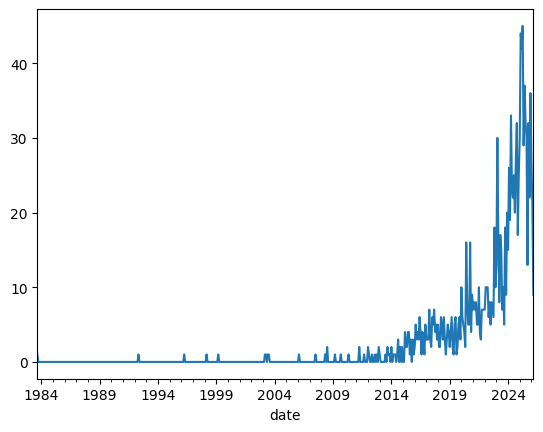

In [63]:
# Incidents per month as a trend line
df.set_index('date').resample('ME').size().plot(kind='line')


In [64]:
# Only big tech companies
big_tech = ['openai', 'google', 'meta', 'amazon', 'microsoft']
deployers_df[deployers_df['deployers'].isin(big_tech)]


,incident_id,date,deployers
3,18,2015-04-04,google
5,15,2008-05-23,amazon
8,6,2016-03-24,microsoft
13,14,2017-10-26,google
14,16,2015-06-03,google
...,...,...,...
1389,1401,2026-02-27,amazon
1403,1415,2026-03-04,openai
1406,1418,2026-02-27,meta
1419,1431,2025-09-29,google


In [65]:
# CSET has many boolean columns — melt collapses them into rows
cset_melted = cset[['Incident ID', 'Physical Objects', 'Detrimental Content', 'Rights Violation']].melt(
    id_vars='Incident ID',
    var_name='harm_type',
    value_name='value'
)